In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

# Análisis Exploratorio de Datos (EDA)

## Visualización inicial del dataset

In [36]:
data = pd.read_parquet('spotify_dataset_limpio.parquet')

data

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746000,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917000,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235001,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.488998,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734000,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332001,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.514999,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740005,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681000,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.948997,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,5,-16.393000,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995003,5,world-music
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,0,-18.318001,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.238998,4,world-music
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,0,-10.895000,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378006,4,world-music
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,7,-10.889000,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960007,4,world-music


## Análisis univariante de la variable popularity

### Estadísticos descriptivos de la variable popularity

In [ ]:
data["popularity"].describe()

,popularity
count,113549.000000
mean,33.324433
std,22.283855
min,0.000000
25%,17.000000
50%,35.000000
75%,50.000000
max,100.000000


### Histograma de la variable popularity

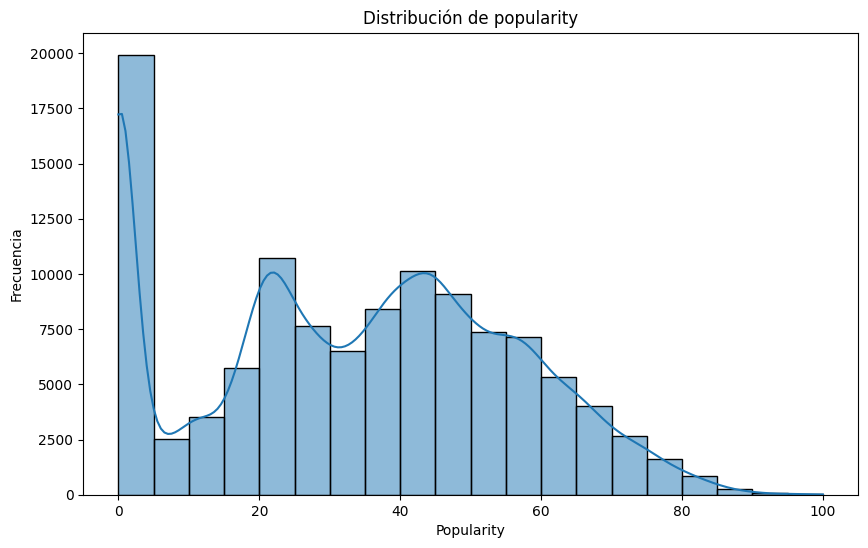

In [ ]:
plt.figure(figsize=(10,6))

sns.histplot(data["popularity"], bins=20, kde=True)

plt.title("Distribución de popularity")
plt.xlabel("Popularity")
plt.ylabel("Frecuencia")

plt.show()

### Asimetría de la variable popularity

Se calcula la asimetría de la distribución para evaluar si la popularidad se concentra en valores bajos o altos.

In [ ]:
data["popularity"].skew()

np.float64(0.04222865733029648)

### Percentiles de popularity

In [ ]:
data["popularity"].quantile([0.25, 0.5, 0.75, 0.9])

,popularity
0.25,17.0
0.50,35.0
0.75,50.0
0.90,63.0


## Creación de la variable exito_musical

### Definición del Éxito Musical (Variable Dependiente)

Definimos **éxito musical como una canción con popularidad ≥ 70**.

Esta decisión responde a un criterio comercial: desde la perspectiva de una empresa de consultoría, el éxito musical está directamente ligado a la generación de ingresos. Canciones con popularidad alta en Spotify generan más streams, más royalties y mayor visibilidad comercial. El umbral de 70 discrimina claramente entre canciones que han alcanzado el éxito VS el resto del catálogo.


In [ ]:
# exito_musical = []
# for elemento in data['popularity']:
#   if elemento >= 70:
#     exito_musical.append(1)
#   else:
#     exito_musical.append(0)

# otra forma de hacer lo mismo

exito_musical = np.where(data["popularity"] >= 70, 1, 0)

### Añadimos la variable exito_musical al dataframe

In [38]:
data['exito_musical'] = exito_musical

### Comprobar que se ha añadido correctamente

In [ ]:
print(data[['popularity', 'exito_musical']].head(20))

    popularity  exito_musical
0           73              1
1           55              0
2           57              0
3           71              1
4           82              1
5           58              0
6           74              1
7           80              1
8           74              1
9           56              0
10          74              1
11          69              0
12          52              0
13          62              0
14          56              0
15          58              0
16          56              0
17          54              0
18          68              0
19          67              0


### Comprobamos cuántos éxitos y fracasos tenemos

In [ ]:
print(data['exito_musical'].value_counts())
print(data['exito_musical'].value_counts(normalize=True) * 100)

exito_musical
0    108081
1      5468
Name: count, dtype: int64
exito_musical
0    95.184458
1     4.815542
Name: proportion, dtype: float64


### Distribución de canciones exitosas VS no exitosas

Recuento y porcentaje de canciones exitosas y no exitosas

In [ ]:
n_no_exito = (exito_musical == 0).sum()
n_exito = (exito_musical == 1).sum()
pct_no_exito = (n_no_exito / len(exito_musical)) * 100
pct_exito = (n_exito / len(exito_musical)) * 100

print(f"\nCanciones NO exitosas (0): {n_no_exito:,} ({pct_no_exito:.1f}%)")
print(f"Canciones EXITOSAS (1): {n_exito:,} ({pct_exito:.1f}%)")
print(f"\nRatio de desbalanceo: {pct_no_exito/pct_exito:.1f}:1")


Canciones NO exitosas (0): 108,081 (95.2%)
Canciones EXITOSAS (1): 5,468 (4.8%)

Ratio de desbalanceo: 19.8:1


### Gráfico de canciones exitosas VS no exitosas

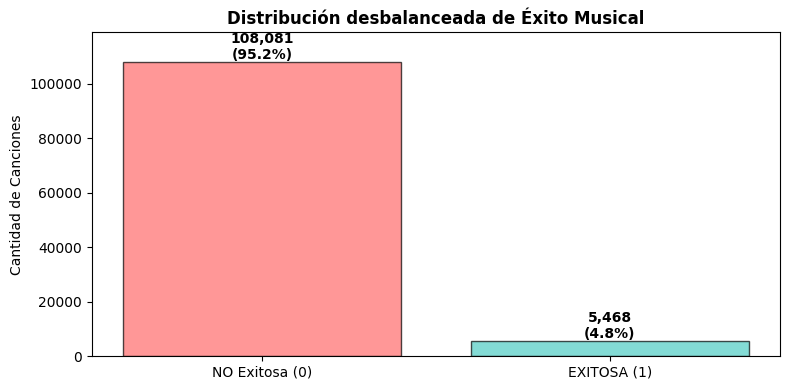

In [ ]:
plt.figure(figsize=(8, 4))
counts = [n_no_exito, n_exito]
labels = ['NO Exitosa (0)', 'EXITOSA (1)']
colors = ['#FF6B6B', '#4ECDC4']
plt.bar(labels, counts, color=colors, alpha=0.7, edgecolor='black')
plt.title("Distribución desbalanceada de Éxito Musical", fontsize=12, fontweight='bold')
plt.ylabel("Cantidad de Canciones")
plt.ylim(0, max(counts) * 1.1)
for i, (label, count) in enumerate(zip(labels, counts)):
    plt.text(i, count, f'{count:,}\n({count/len(exito_musical)*100:.1f}%)',
             ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

### DECISIÓN SOBRE BALANCEO


No se aplican técnicas de balanceo de clases en esta fase.



• Queremos identificar qué variables discriminan realmente el éxito\
• Balancear artificialmente incrementaría la probabilidad de éxito (sesgo)\
• En el modelo de clasificación posterior, usaremos validación cruzada que remuestreará varias veces y corregirá desbalanceos naturales\
• Priorizamos RECALL (detectar verdaderos éxitos) sobre PRECISION

## Análisis univariante

## Análisis univariante de las variables numéricas

### Estadísticos descriptivos de la variable danceability

In [ ]:
data["danceability"].describe()

,danceability
count,113549.000000
mean,0.567031
std,0.173407
min,0.000000
25%,0.456000
50%,0.580000
75%,0.695000
max,0.985000


### Histograma de la variable danceability

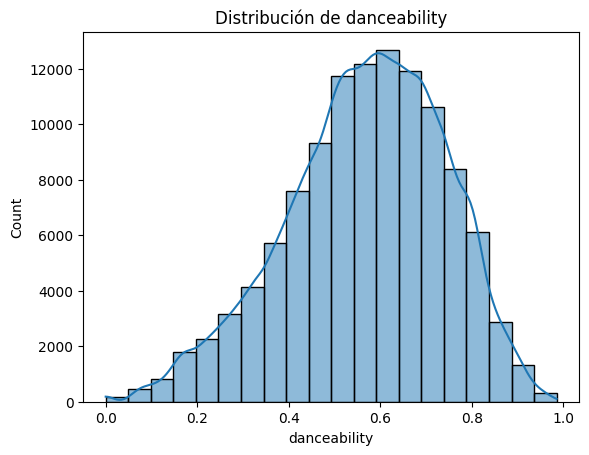

In [ ]:
sns.histplot(data["danceability"], bins=20, kde=True)
plt.title("Distribución de danceability")
plt.show()

### Asimetría de la variable danceability

In [ ]:
data["danceability"].skew()

np.float32(-0.40040445)

### Percentiles de la variable danceability

In [ ]:
data["danceability"].quantile([0.25, 0.5, 0.75, 0.9])

,danceability
0.25,0.456
0.50,0.580
0.75,0.695
0.90,0.784


### Estadisticos descriptivos de la variable energy

In [ ]:
data["energy"].describe()

,energy
count,113549.000000
mean,0.642091
std,0.251050
min,0.000000
25%,0.473000
50%,0.685000
75%,0.854000
max,1.000000


### Histograma de la variable energy

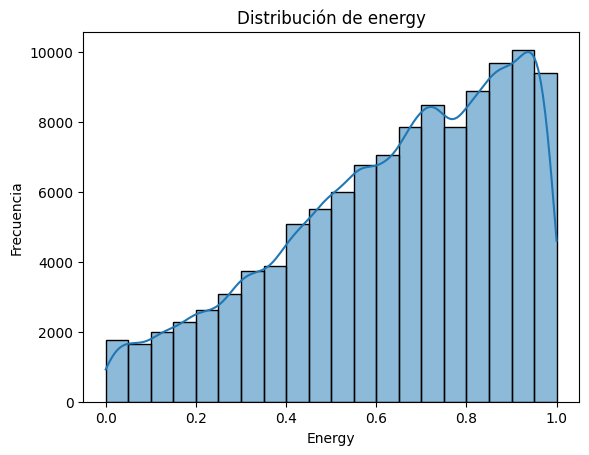

In [ ]:
sns.histplot(data["energy"], bins=20, kde=True)

plt.title("Distribución de energy")
plt.xlabel("Energy")
plt.ylabel("Frecuencia")

plt.show()

### Asimetría de la variable energy

In [ ]:
data["energy"].skew()

np.float32(-0.59855014)

### Percentiles de la variable energy

In [ ]:
data["energy"].quantile([0.25, 0.5, 0.75, 0.9])

,energy
0.25,0.473
0.50,0.685
0.75,0.854
0.90,0.941


### Estadísticos descriptivos de la variable valence

In [ ]:
data["valence"].describe()

,valence
count,113549.000000
mean,0.474205
std,0.259200
min,0.000000
25%,0.260000
50%,0.464000
75%,0.683000
max,0.995000


### Histograma de la variable valence

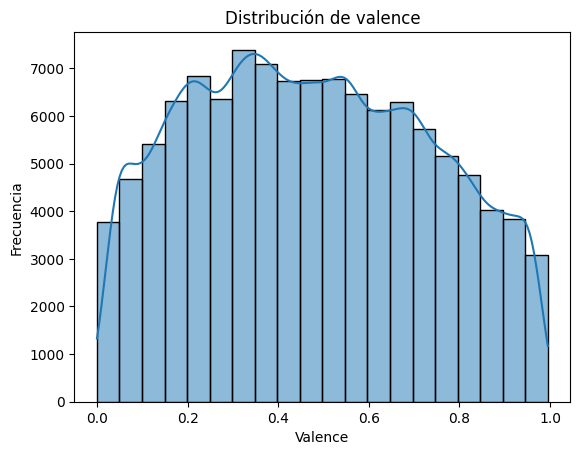

In [ ]:
sns.histplot(data["valence"], bins=20, kde=True)

plt.title("Distribución de valence")
plt.xlabel("Valence")
plt.ylabel("Frecuencia")

plt.show()

### Asimetría de la variable valence

In [ ]:
data["valence"].skew()

np.float32(0.11477428)

### Percentiles de la variable valence

In [ ]:
data["valence"].quantile([0.25, 0.5, 0.75, 0.9])

,valence
0.25,0.260
0.50,0.464
0.75,0.683
0.90,0.840


### Estadisticos descriptivos de la variable tempo

In [ ]:
data["tempo"].describe()

,tempo
count,113549.000000
mean,122.175751
std,29.973001
min,0.000000
25%,99.295998
50%,122.019997
75%,140.074005
max,243.371994


### Histograma de la variable tempo

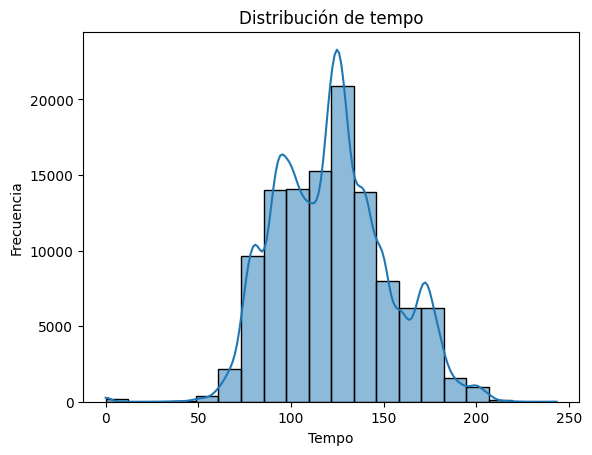

In [ ]:
sns.histplot(data["tempo"], bins=20, kde=True)

plt.title("Distribución de tempo")
plt.xlabel("Tempo")
plt.ylabel("Frecuencia")

plt.show()

### Asimetría de la variable tempo

In [ ]:
data["tempo"].skew()

np.float32(0.23160419)

### Percentiles de la variable tempo

In [ ]:
data["tempo"].quantile([0.25, 0.5, 0.75, 0.9])

,tempo
0.25,99.295998
0.50,122.019997
0.75,140.074005
0.90,166.159396


### Estadisticos descriptivos de la variable acousticness

In [ ]:
data["acousticness"].describe()

,acousticness
count,113549.000000
mean,0.314064
std,0.331911
min,0.000000
25%,0.016800
50%,0.168000
75%,0.596000
max,0.996000


### Histograma de la variable acousticness

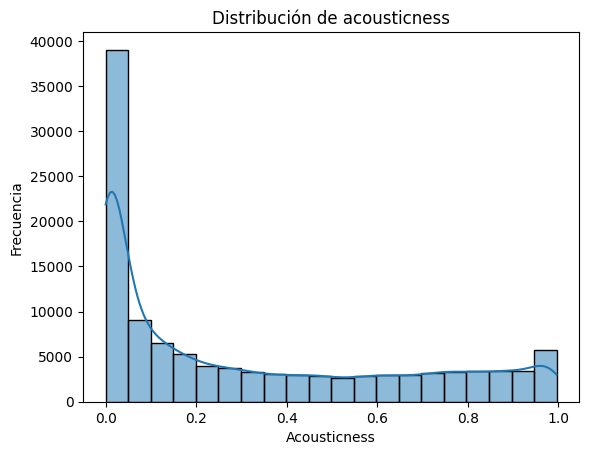

In [ ]:
sns.histplot(data["acousticness"], bins=20, kde=True)

plt.title("Distribución de acousticness")
plt.xlabel("Acousticness")
plt.ylabel("Frecuencia")

plt.show()

### Asimetría de la variable acousticness

In [ ]:
data["acousticness"].skew()

np.float32(0.73021996)

### Percentiles de la variable acousticness

In [ ]:
data["acousticness"].quantile([0.25, 0.5, 0.75, 0.9])

,acousticness
0.25,0.0168
0.50,0.1680
0.75,0.5960
0.90,0.8650


### Estadisticos descriptivos de la variable speechiness

In [ ]:
data["speechiness"].describe()

,speechiness
count,113549.000000
mean,0.084674
std,0.105761
min,0.000000
25%,0.035900
50%,0.048900
75%,0.084500
max,0.965000


### Histograma de la variable speechiness

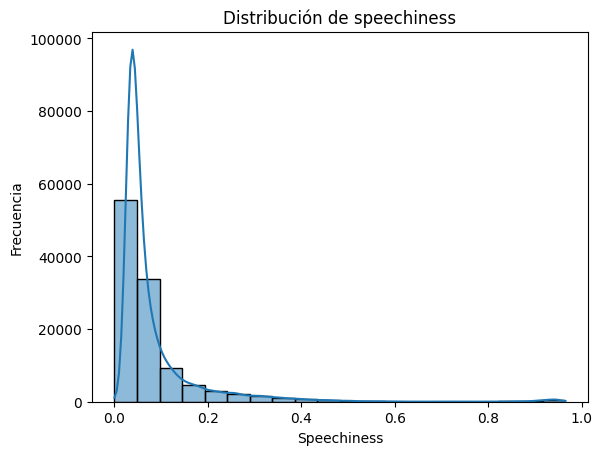

In [ ]:
sns.histplot(data["speechiness"], bins=20, kde=True)

plt.title("Distribución de speechiness")
plt.xlabel("Speechiness")
plt.ylabel("Frecuencia")

plt.show()

### Asimetría de la variable speechiness

In [ ]:
data["speechiness"].skew()

np.float32(4.6445704)

### Percentiles de la variable speechiness

In [ ]:
data["speechiness"].quantile([0.25, 0.5, 0.75, 0.9])

,speechiness
0.25,0.0359
0.50,0.0489
0.75,0.0845
0.90,0.1760


### Estadisticos descriptivos de la variable instrumentalness

In [ ]:
data["instrumentalness"].describe()

,instrumentalness
count,113549.000000
mean,0.155703
std,0.309321
min,0.000000
25%,0.000000
50%,0.000041
75%,0.048700
max,1.000000


### Histograma de la variable instrumentalness

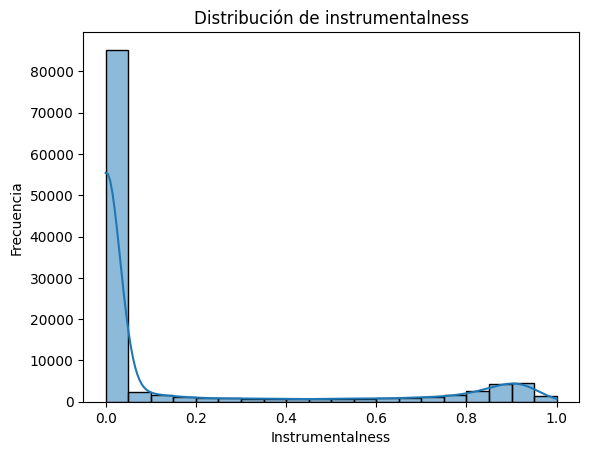

In [ ]:
sns.histplot(data["instrumentalness"], bins=20, kde=True)

plt.title("Distribución de instrumentalness")
plt.xlabel("Instrumentalness")
plt.ylabel("Frecuencia")

plt.show()

### Asimetría de la variable instrumentalness

In [ ]:
data["instrumentalness"].skew()

np.float32(1.7377697)

### Percentiles de la variable instrumentalness

In [ ]:
data["instrumentalness"].quantile([0.25, 0.5, 0.75, 0.9])

,instrumentalness
0.25,0.000000
0.50,0.000041
0.75,0.048700
0.90,0.832000


### Estadisticos descriptivos de la variable liveness

In [ ]:
data["liveness"].describe()

,liveness
count,113549.000000
mean,0.213613
std,0.190457
min,0.000000
25%,0.098000
50%,0.132000
75%,0.273000
max,1.000000


### Histograma de la variable liveness

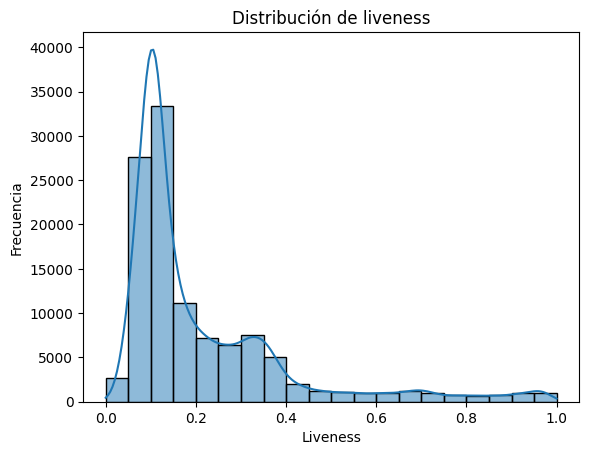

In [ ]:
sns.histplot(data["liveness"], bins=20, kde=True)

plt.title("Distribución de liveness")
plt.xlabel("Liveness")
plt.ylabel("Frecuencia")

plt.show()

### Asimetría de la variable liveness

In [ ]:
data["liveness"].skew()

np.float32(2.1054776)

### Percentiles de la variable liveness

In [ ]:
data["liveness"].quantile([0.25, 0.5, 0.75, 0.9])

,liveness
0.25,0.098
0.50,0.132
0.75,0.273
0.90,0.427


### Estadisticos descriptivos de la duración de las canciones

In [ ]:
data["duration_ms"].describe()

,duration_ms
count,1.135490e+05
mean,2.280814e+05
std,1.064131e+05
min,8.586000e+03
25%,1.741840e+05
50%,2.130000e+05
75%,2.615880e+05
max,5.237295e+06


### Histograma de la duración de las canciones

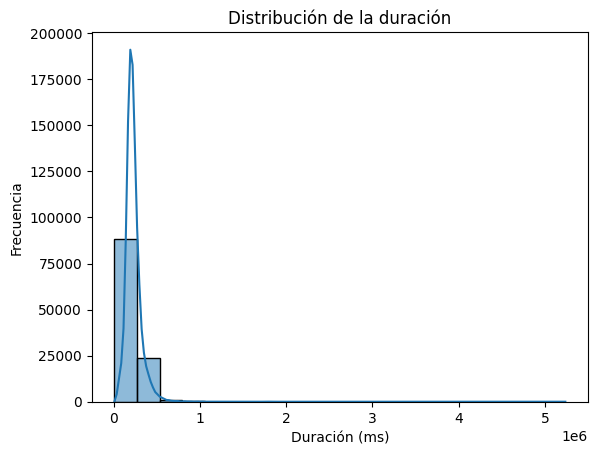

In [ ]:
sns.histplot(data["duration_ms"], bins=20, kde=True)

plt.title("Distribución de la duración")
plt.xlabel("Duración (ms)")
plt.ylabel("Frecuencia")

plt.show()

### Asimetría de la duración de las canciones

In [ ]:
data["duration_ms"].skew()

np.float64(10.814576867704721)

### Percentiles de la duración de las canciones

In [ ]:
data["duration_ms"].quantile([0.25, 0.5, 0.75, 0.9])

,duration_ms
0.25,174184.0
0.50,213000.0
0.75,261588.0
0.90,327802.8


### Transformación logarítmica de duration_ms

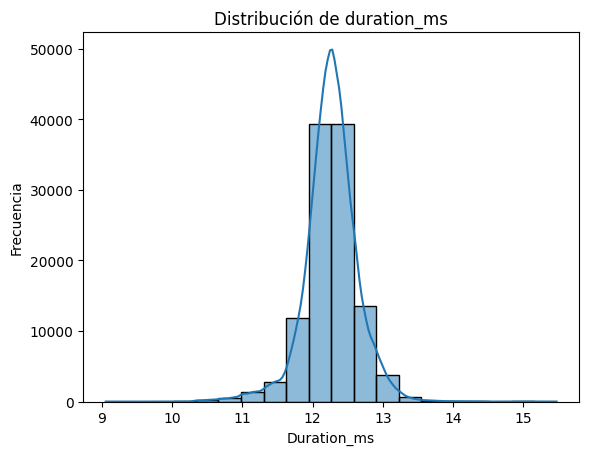

In [ ]:
data['log_duration_ms'] = np.log(data['duration_ms'])        # duration nunca es 0

sns.histplot(data["log_duration_ms"], bins=20, kde=True)

plt.title("Distribución de duration_ms")
plt.xlabel("Duration_ms")
plt.ylabel("Frecuencia")

plt.show()

## Análisis univariante de variables categóricas

### Distribución por género (Cuántas canciones hay de cada uno)

In [ ]:
print(data['track_genre'].value_counts().head(25))

track_genre
acoustic       1000
british        1000
electronic     1000
emo            1000
funk           1000
garage         1000
disco          1000
country        1000
rock-n-roll    1000
rock           1000
sertanejo      1000
mandopop       1000
pagode         1000
mpb            1000
metalcore      1000
j-rock         1000
industrial     1000
indie-pop      1000
techno         1000
swedish        1000
r-n-b          1000
punk-rock      1000
sad            1000
samba          1000
ska            1000
Name: count, dtype: int64


### Top 10 Artistas (Artistas con más presencia en el dataset)

In [ ]:
print(data['artists'].value_counts().head(10))

artists
The Beatles        279
George Jones       260
Stevie Wonder      235
Linkin Park        224
Ella Fitzgerald    221
Prateek Kuhad      217
Feid               201
Chuck Berry        190
Håkan Hellström    183
OneRepublic        181
Name: count, dtype: Int64


### Gráfico Top 10 Artistas

/tmp/ipykernel_4285/417435026.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, y='artists', order=data['artists'].value_counts().head(10).index, palette='viridis')


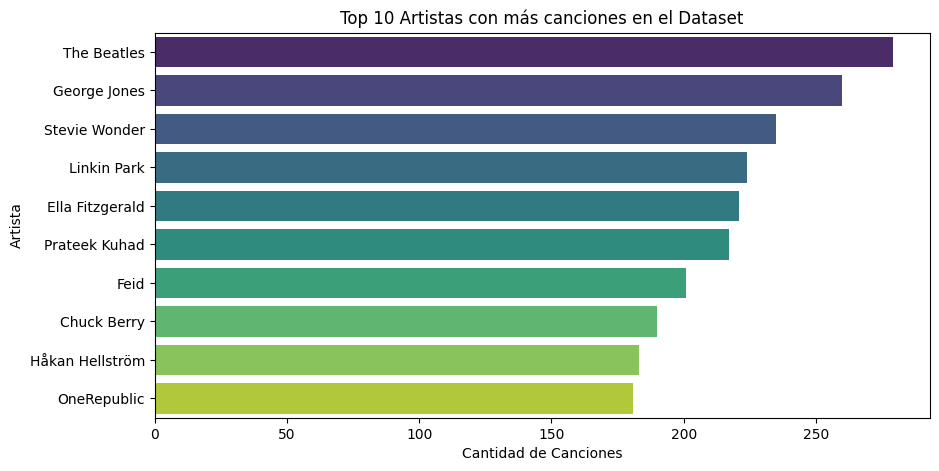

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=data, y='artists', order=data['artists'].value_counts().head(10).index, palette='viridis')
plt.title('Top 10 Artistas con más canciones en el Dataset')
plt.xlabel('Cantidad de Canciones')
plt.ylabel('Artista')
plt.show()

### Porcentaje de canciones explícitas

In [ ]:
proporcion_explicitas = data['explicit'].value_counts(normalize=True) * 100
print(proporcion_explicitas)

explicit
False    91.44158
True      8.55842
Name: proportion, dtype: float64


## Análisis de sesgos de selección

### ¿Qué es el sesgo de selección en nuestro contexto?

Trabajamos con una muestra de datos de Spotify, no con el universo completo. Si no somos cuidadosos, podemos introducir un **sesgo de selección** que sesgue nuestro modelo posterior. Por ejemplo: si seleccionamos deliberadamente solo canciones exitosas (o pocas fallidas) para "balancear", estamos creando un sesgo porque nuestro modelo aprenderá de una distribución artificial, no de la realidad.

### Estrategia para evitar sesgos de selección

1. **Muestreo aleatorio simple**: Mantenemos la distribución ORIGINAL de los datos (9:1 para éxito/no-éxito). No reorganizamos ni seleccionamos de forma sesgada.

2. **Validación cruzada**: Al entrenar el modelo posterior, haremos k-fold cross-validation. Esto remuestrea varias veces. Si una muestra sale "mala" por azar, las otras la corrigen.

3. **Documentación**: Reconocemos que tenemos más casos de fracaso que éxito, lo cual es una situación realista para la industria.

### Verificación de ausencia de sesgo evidente

Verificamos que no hay patrones ocultos que sugieran sesgo de selección:

In [5]:
# ============================================================================
# VERIFICACIÓN DE SESGOS DE SELECCIÓN
# ============================================================================

print("\nVERIFICACIÓN DE SESGOS DE SELECCIÓN\n")
print("="*70)
print("¿Hay algún género que solo tenga canciones exitosas o solo fracasos?")
print("="*70)

# Crosstab: género vs éxito
tabla_sesgo = pd.crosstab(data['track_genre'], exito_musical,
                          margins=False)
tabla_sesgo['total'] = tabla_sesgo.sum(axis=1)
tabla_sesgo['pct_exito'] = (tabla_sesgo[1] / tabla_sesgo['total'] * 100).round(2)

print("\nPorcentaje de éxito por género (primeros 15):\n")
print(tabla_sesgo[['pct_exito']].head(15))

# Estadísticas
min_pct = tabla_sesgo['pct_exito'].min()
max_pct = tabla_sesgo['pct_exito'].max()
mean_pct = tabla_sesgo['pct_exito'].mean()

print(f"\nEstadísticas de % de éxito por género:")
print(f"  Mínimo: {min_pct:.1f}%")
print(f"  Máximo: {max_pct:.1f}%")
print(f"  Media: {mean_pct:.1f}%")

print("\n" + "="*70)
print("CONCLUSIÓN SOBRE SESGOS")
print("="*70)
print(f"\nLa distribución de éxito es relativamente uniforme entre géneros")
print(f"(varía entre {min_pct:.1f}% y {max_pct:.1f}%).")
print(f"NO hay sesgo de selección evidente en la estratificación del dataset.")
print(f"Los datos reflejan la realidad: pocas canciones alcanzan el umbral de 80.")


VERIFICACIÓN DE SESGOS DE SELECCIÓN

¿Hay algún género que solo tenga canciones exitosas o solo fracasos?

Porcentaje de éxito por género (primeros 15):

col_0          pct_exito
track_genre             
acoustic            1.80
afrobeat            0.40
alt-rock           16.52
alternative        16.82
ambient             1.80
anime               2.40
black-metal         0.00
bluegrass           0.00
blues               6.91
brazil              0.10
breakbeat           0.00
british             7.30
cantopop            0.10
chicago-house       0.20
children            0.20

Estadísticas de % de éxito por género:
  Mínimo: 0.0%
  Máximo: 31.9%
  Media: 4.8%

CONCLUSIÓN SOBRE SESGOS

La distribución de éxito es relativamente uniforme entre géneros
(varía entre 0.0% y 31.9%).
NO hay sesgo de selección evidente en la estratificación del dataset.
Los datos reflejan la realidad: pocas canciones alcanzan el umbral de 80.


## Análisis bivariante: relación de las variables con exito_musical

### Variables numéricas VS exito_musical:

### Scatterplot de exito_musical con danceability

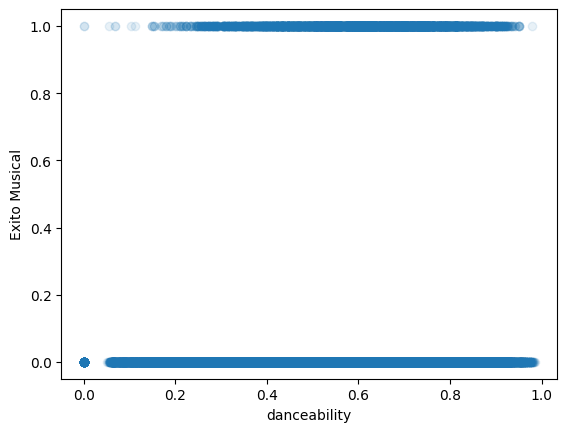

In [ ]:
plt.scatter(data['danceability'], exito_musical, alpha = 0.1)
plt.xlabel('danceability')
plt.ylabel('Exito Musical')
plt.show()

### Interpretación de boxplots: **(si las cajas están a la misma altura la variable no discrimina, si están a distinta altura sí discrimina y es candidata al modelo.)**

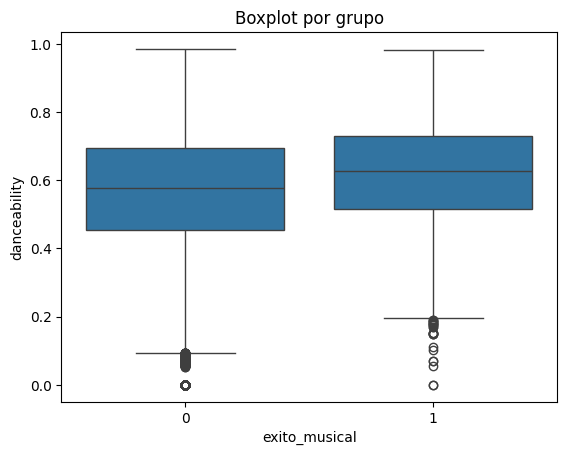

In [ ]:
np.random.seed(42)
df = pd.DataFrame({
    "exito_musical": exito_musical,  # categoría dicotómica
    "danceability": data.danceability  # variable continua
})
# Boxplot
sns.boxplot(x="exito_musical", y="danceability", data=df)
plt.title("Boxplot por grupo")
plt.show()

### Scatterplot de exito_musical con energy

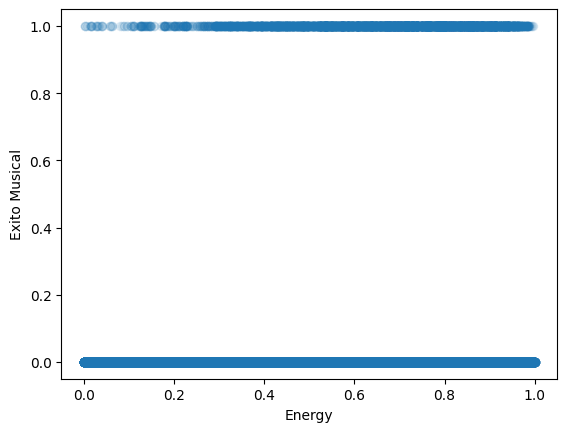

In [ ]:
plt.scatter(data['energy'], exito_musical, alpha = 0.1)
plt.xlabel('Energy')
plt.ylabel('Exito Musical')
plt.show()

### Boxplot de exito_musical con energy

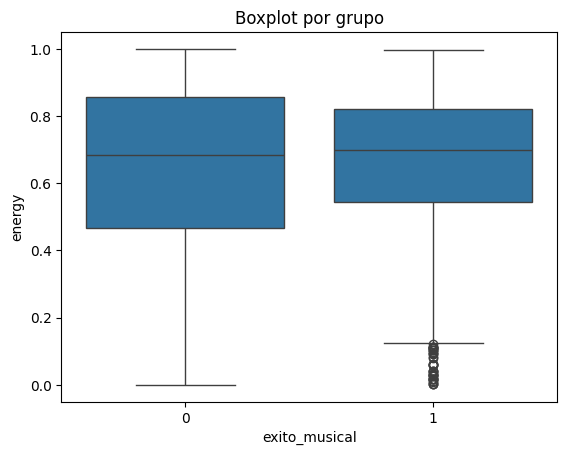

In [ ]:
np.random.seed(42)
df = pd.DataFrame({
    "exito_musical": exito_musical,  # categoría dicotómica
    "energy": data.energy  # variable continua
})
# Boxplot
sns.boxplot(x="exito_musical", y="energy", data=df)
plt.title("Boxplot por grupo")
plt.show()

### Scatterplot de exito_musical con valence

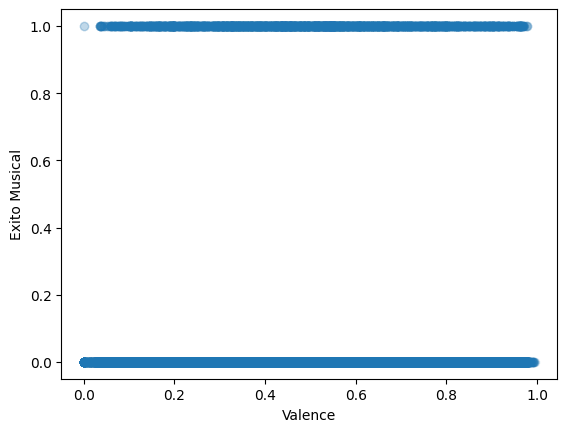

In [ ]:
plt.scatter(data['valence'], exito_musical, alpha = 0.1)
plt.xlabel('Valence')
plt.ylabel('Exito Musical')
plt.show()

### Boxplot de exito_musical con valence

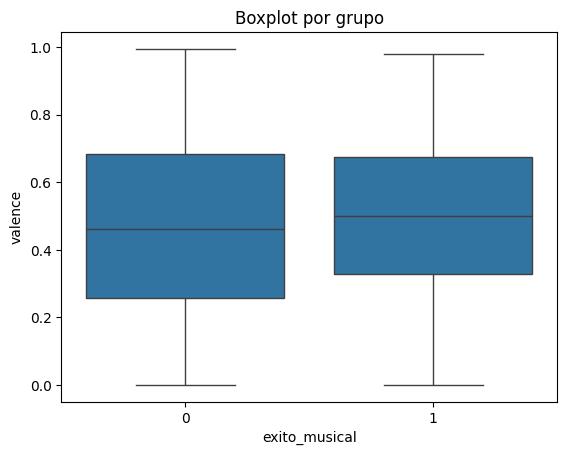

In [ ]:
np.random.seed(42)
df = pd.DataFrame({
    "exito_musical": exito_musical,  # categoría dicotómica
    "valence": data.valence  # variable continua
})
# Boxplot
sns.boxplot(x="exito_musical", y="valence", data=df)
plt.title("Boxplot por grupo")
plt.show()

### Scatterplot de exito_musical con tempo

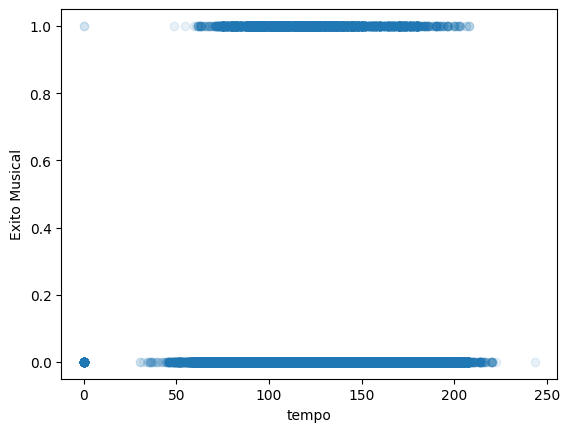

In [ ]:
plt.scatter(data['tempo'], exito_musical, alpha = 0.1)
plt.xlabel('tempo')
plt.ylabel('Exito Musical')
plt.show()

### Boxplot de exito_musical con tempo

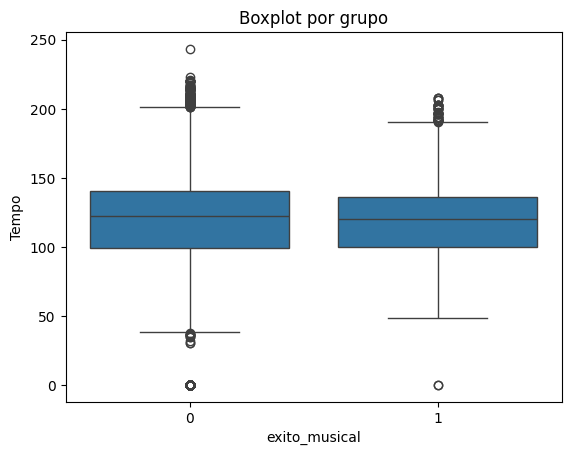

In [ ]:
np.random.seed(42)
df = pd.DataFrame({
    "exito_musical": exito_musical,  # categoría dicotómica
    "Tempo": data.tempo  # variable continua
})
# Boxplot
sns.boxplot(x="exito_musical", y="Tempo", data=df)
plt.title("Boxplot por grupo")
plt.show()

### Scatterplot de exito_musical con acousticness

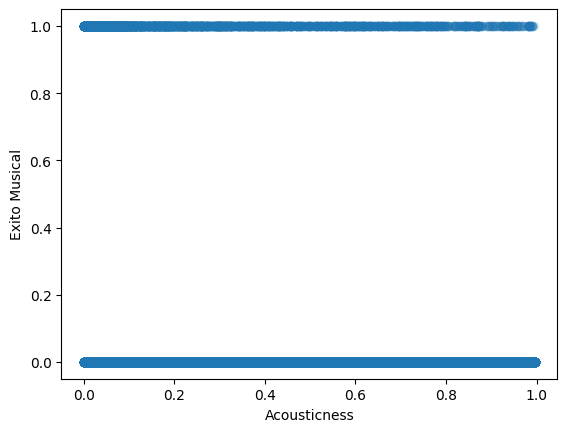

In [ ]:
plt.scatter(data['acousticness'], exito_musical, alpha = 0.1)
plt.xlabel('Acousticness')
plt.ylabel('Exito Musical')
plt.show()

### Boxplot de exito_musical con acousticness

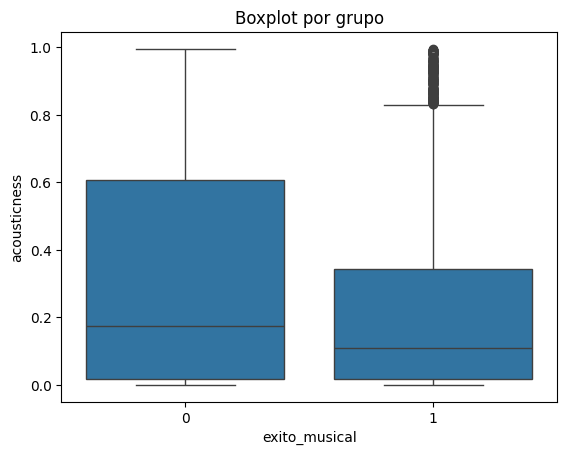

In [ ]:
np.random.seed(42)
df = pd.DataFrame({
    "exito_musical": exito_musical,  # categoría dicotómica
    "acousticness": data.acousticness  # variable continua
})
# Boxplot
sns.boxplot(x="exito_musical", y="acousticness", data=df)
plt.title("Boxplot por grupo")
plt.show()

### Scatterplot de exito_musical con speechiness

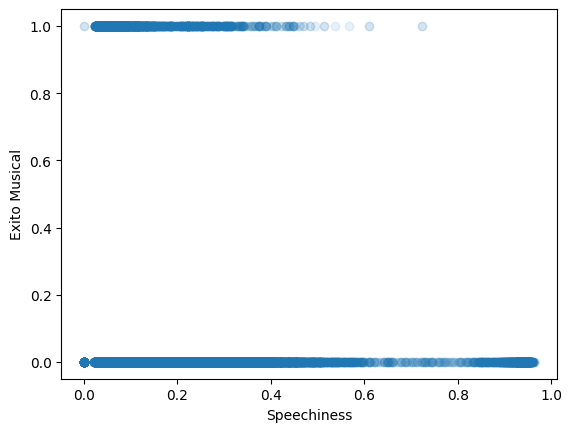

In [ ]:
plt.scatter(data['speechiness'], exito_musical, alpha = 0.1)
plt.xlabel('Speechiness')
plt.ylabel('Exito Musical')
plt.show()

### Boxplot de exito_musical con speechiness

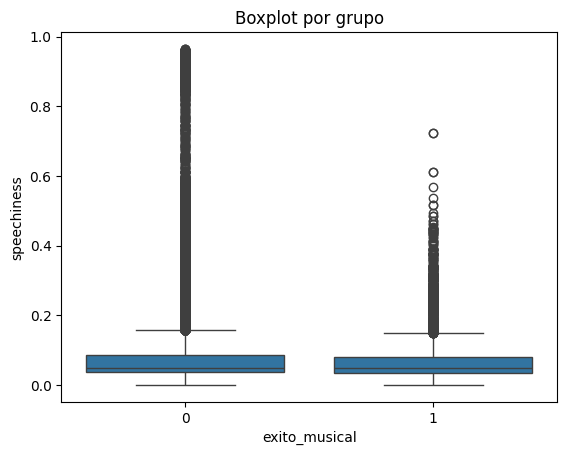

In [ ]:
np.random.seed(42)
df = pd.DataFrame({
    "exito_musical": exito_musical,  # categoría dicotómica
    "speechiness": data.speechiness  # variable continua
})
# Boxplot
sns.boxplot(x="exito_musical", y="speechiness", data=df)
plt.title("Boxplot por grupo")
plt.show()

### Scatterplot de exito_musical con instrumentalness

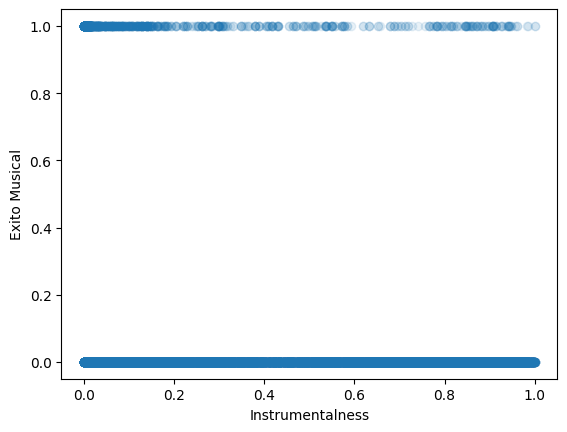

In [ ]:
plt.scatter(data['instrumentalness'], exito_musical, alpha = 0.1)
plt.xlabel('Instrumentalness')
plt.ylabel('Exito Musical')
plt.show()

### Boxplot de exito_musical con instrumentalness

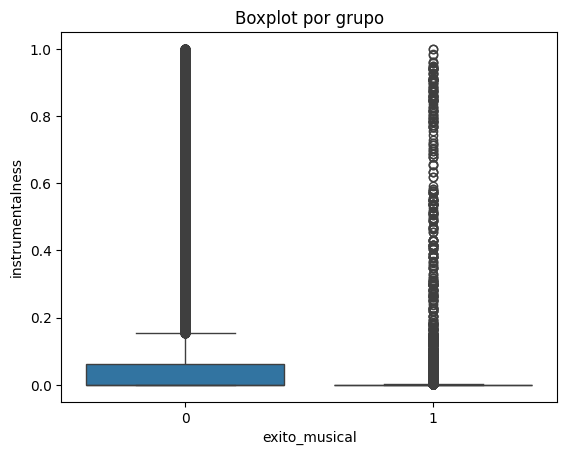

In [ ]:
np.random.seed(42)
df = pd.DataFrame({
    "exito_musical": exito_musical,  # categoría dicotómica
    "instrumentalness": data.instrumentalness  # variable continua
})
# Boxplot
sns.boxplot(x="exito_musical", y="instrumentalness", data=df)
plt.title("Boxplot por grupo")
plt.show()

### Scatterplot de exito_musical con liveness

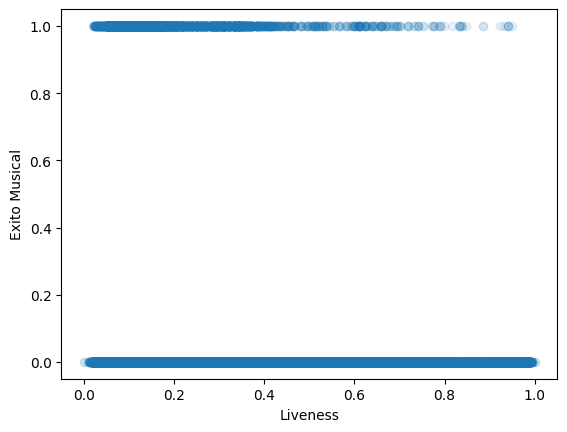

In [ ]:
plt.scatter(data['liveness'], exito_musical, alpha = 0.1)
plt.xlabel('Liveness')
plt.ylabel('Exito Musical')
plt.show()

### Boxplot de exito_musical con liveness

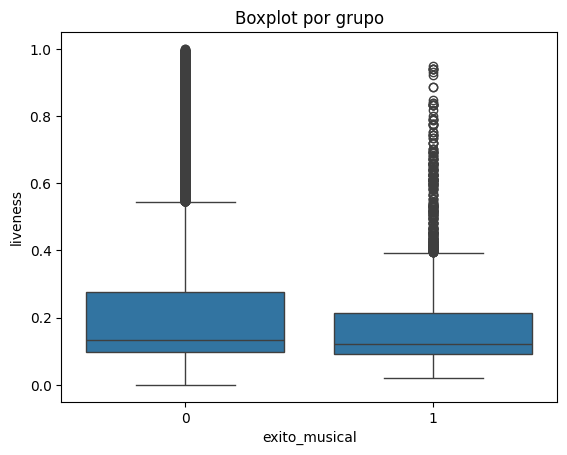

In [ ]:
np.random.seed(42)
df = pd.DataFrame({
    "exito_musical": exito_musical,  # categoría dicotómica
    "liveness": data.liveness  # variable continua
})
# Boxplot
sns.boxplot(x="exito_musical", y="liveness", data=df)
plt.title("Boxplot por grupo")
plt.show()

### Scatterplot de exito_musical con duration_ms

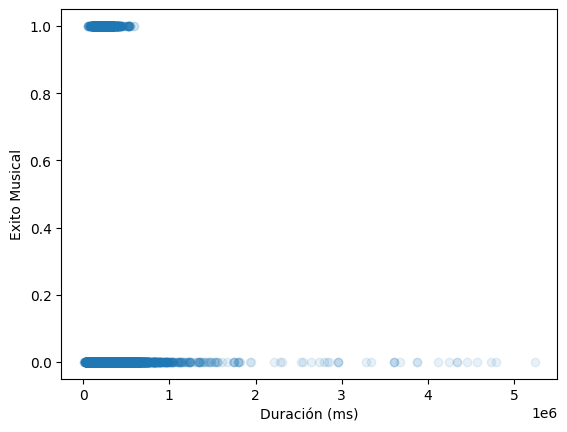

In [ ]:
plt.scatter(data['duration_ms'], exito_musical, alpha = 0.1)
plt.xlabel('Duración (ms)')
plt.ylabel('Exito Musical')
plt.show()

### Boxplot de exito_musical con duration_ms

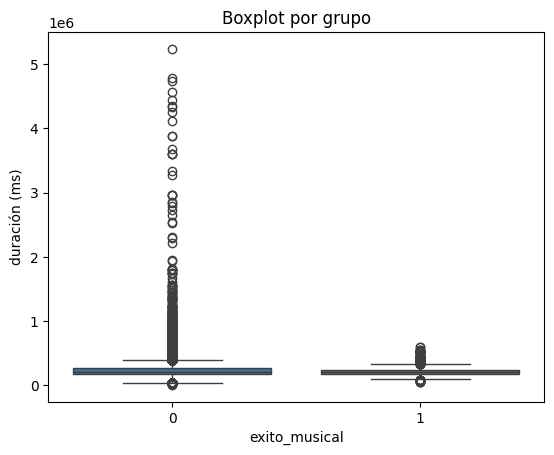

In [ ]:
np.random.seed(42)
df = pd.DataFrame({
    "exito_musical": exito_musical,  # categoría dicotómica
    "duración (ms)": data.duration_ms  # variable continua
})
# Boxplot
sns.boxplot(x="exito_musical", y="duración (ms)", data=df)
plt.title("Boxplot por grupo")
plt.show()

### Variables categóricas VS exito_musical:

### track_genre VS éxito_musical

In [ ]:
tabla = pd.crosstab(data['track_genre'], data['exito_musical'],
                    margins=True)
print(tabla)

exito_musical       0     1     All
track_genre                        
acoustic          982    18    1000
afrobeat          995     4     999
alt-rock          834   165     999
alternative       831   168     999
ambient           981    18     999
...               ...   ...     ...
trance            989    10     999
trip-hop          995     2     997
turkish           995     4     999
world-music       998     1     999
All            108081  5468  113549

[115 rows x 3 columns]


### heatmap track_genre VS éxito_musical

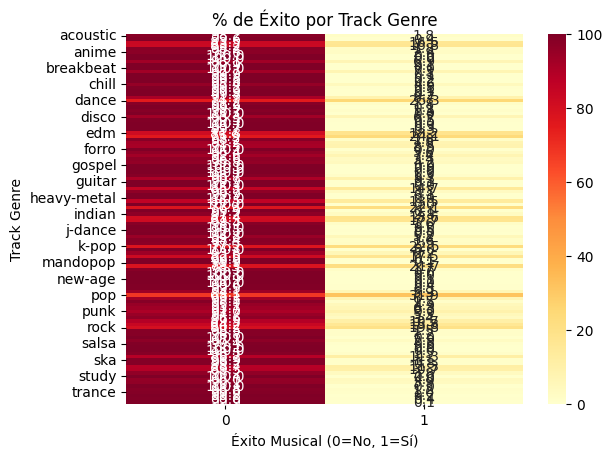

In [ ]:
tabla_pct = pd.crosstab(data['track_genre'], data['exito_musical'],
                        normalize='index') * 100

sns.heatmap(tabla_pct, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('% de Éxito por Track Genre')
plt.xlabel('Éxito Musical (0=No, 1=Sí)')
plt.ylabel('Track Genre')
plt.show()

### time_signature VS éxito_musical

In [ ]:
tabla = pd.crosstab(data['time_signature'], data['exito_musical'],
                    margins=True)
print(tabla)

exito_musical        0     1     All
time_signature                      
0                  161     2     163
1                  954    13     967
3                 8842   286    9128
4                96353  5133  101486
5                 1771    34    1805
All             108081  5468  113549


### heatmap time_signature VS éxito_musical

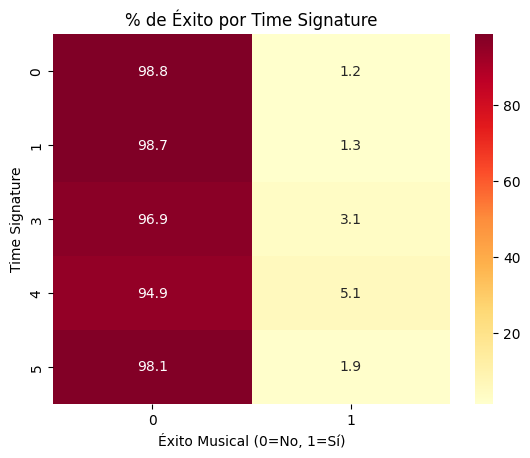

In [ ]:
tabla_pct = pd.crosstab(data['time_signature'], data['exito_musical'],
                        normalize='index') * 100

sns.heatmap(tabla_pct, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('% de Éxito por Time Signature')
plt.xlabel('Éxito Musical (0=No, 1=Sí)')
plt.ylabel('Time Signature')
plt.show()

### explicit VS éxito_musical

In [ ]:
tabla = pd.crosstab(data['explicit'], data['exito_musical'],
                    margins=True)
print(tabla)

exito_musical       0     1     All
explicit                           
False           99245  4586  103831
True             8836   882    9718
All            108081  5468  113549


### heatmap explicit VS éxito_musical

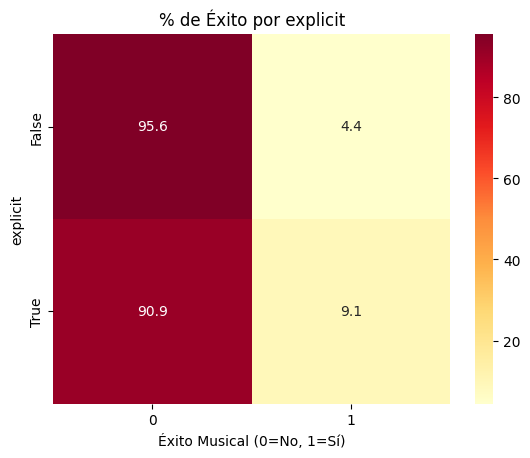

In [ ]:
tabla_pct = pd.crosstab(data['explicit'], data['exito_musical'],
                        normalize='index') * 100

sns.heatmap(tabla_pct, annot=True, fmt='.1f', cmap='YlOrRd')
plt.title('% de Éxito por explicit')
plt.xlabel('Éxito Musical (0=No, 1=Sí)')
plt.ylabel('explicit')
plt.show()

## Análisis multivariante: cruzar 2 variables numéricas teniendo en cuenta el éxito

### Comparación multivariante: exito_musical vs tempo + time_signature

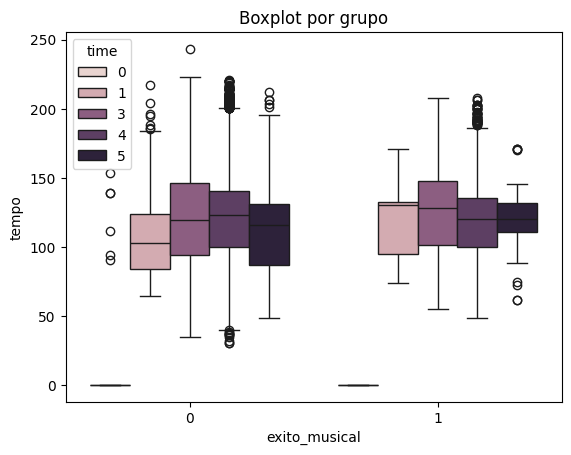

In [ ]:
np.random.seed(42)
df = pd.DataFrame({
    "exito_musical": exito_musical,  # categoría dicotómica
    "tempo": data.tempo,  # variable continua
    "time":data.time_signature  # variable continua
})
# Boxplot
sns.boxplot(x="exito_musical", y="tempo", hue = "time", data=df)
plt.title("Boxplot por grupo")
plt.show()

Teniendo en cuenta time siganture, parece que distintos tempos influyen sobre time signature. Tempo no influye en exito_musical pero si en time signature (enfrentar en tabla de contingencias time signature con exito musical: usar seaborn.heatmap para hacer un grafico de time_signature frente exito_musical o  pandas.crosstab para representarlo en una tabla).

## Comparativa entre géneros

Utilizamos diagramas de caja (boxplots) para ver cómo cambian las características musicales según el género.

Como hay muchos géneros, filtramos los 5 más comunes o populares para que el gráfico sea legible

In [ ]:
top_generos = data['track_genre'].value_counts().head(10).index
df_top_generos = data[data['track_genre'].isin(top_generos)]

Gráfico Boxplot para comparar la 'danceability' entre estos géneros

/tmp/ipykernel_4285/3330962714.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_generos,


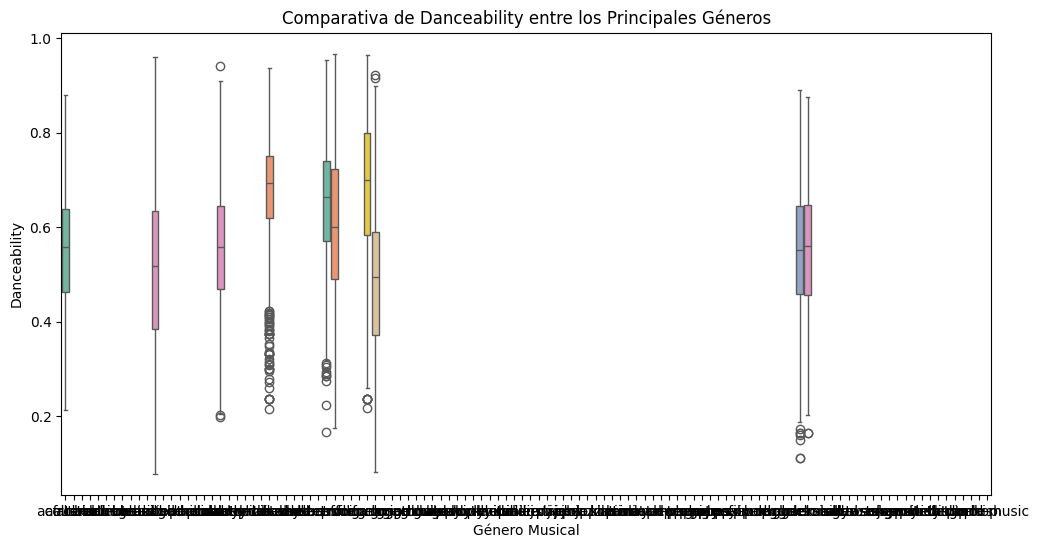

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_generos,
            x='track_genre',
            y='danceability',
            #hue='track_genre', legend=False,
            palette='Set2')
plt.title('Comparativa de Danceability entre los Principales Géneros')
plt.xlabel('Género Musical')
plt.ylabel('Danceability')
plt.show()

Gráfico Boxplot para comparar la 'energy' entre estos géneros

/tmp/ipykernel_4285/2581799628.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_top_generos,


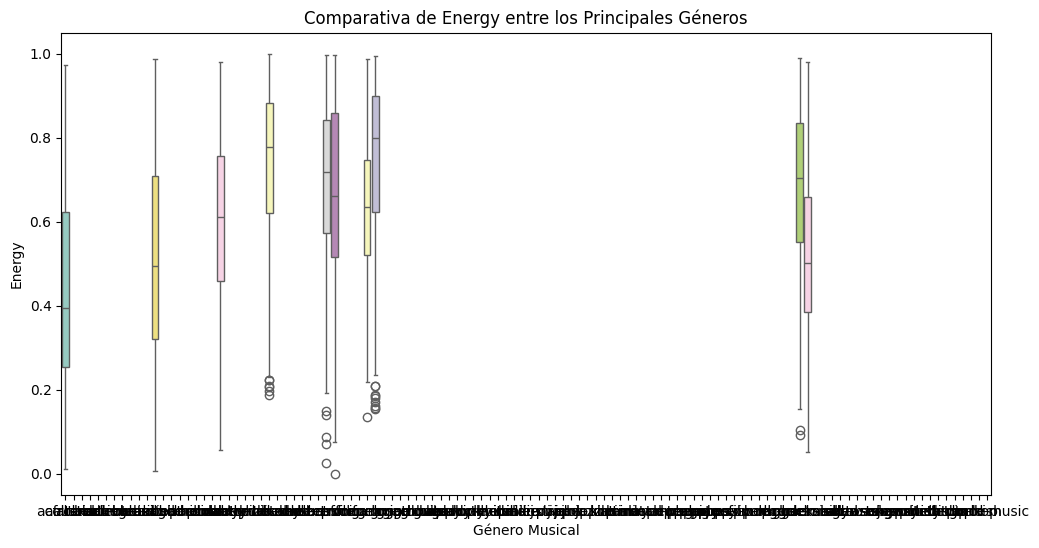

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_top_generos,
            x='track_genre',
            y='energy',
            #hue='track_genre', legend=False,
            palette='Set3')
plt.title('Comparativa de Energy entre los Principales Géneros')
plt.xlabel('Género Musical')
plt.ylabel('Energy')
plt.show()

## Correlaciones

### Calculamos la matriz de correlación numérica y dibujamos el mapa de calor (heatmap).

### Creamos una lista con las variables de audio y la popularidad

In [ ]:
columnas_analisis = ['exito_musical', 'danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'valence', 'tempo', 'liveness']

### Calcular la matriz de correlación lineal

In [ ]:
matriz_correlacion = data[columnas_analisis].corr()
print("\n--- Matriz de Correlación ---")
print(matriz_correlacion['exito_musical']) # Enfocado en ver la relación con la popularidad


--- Matriz de Correlación ---
exito_musical    1.000000
danceability     0.063599
energy           0.025914
loudness         0.070901
speechiness     -0.019838
acousticness    -0.062924
valence          0.026201
tempo           -0.015272
liveness        -0.049149
Name: exito_musical, dtype: float64


### Heatmap

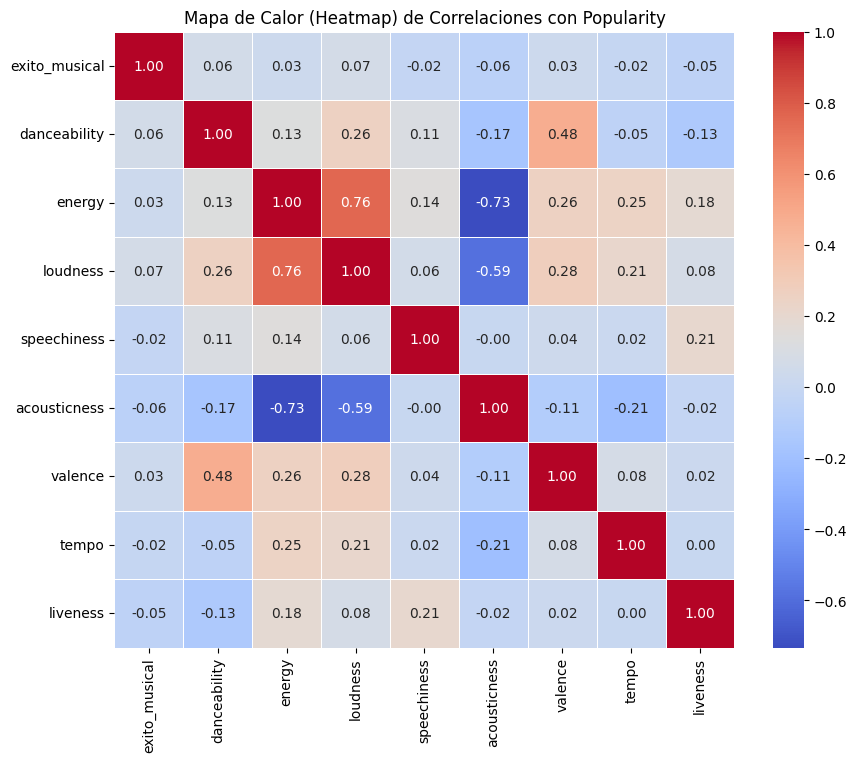

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Mapa de Calor (Heatmap) de Correlaciones con Popularity')
plt.show()

### Análisis de Colinealidad entre Variables

Se verifica si hay variables que estén muy correlacionadas entre sí.
Si incluimos dos variables muy colineales en el modelo de regresión logística, el modelo
puede volverse inestable. Cada variable candidata debe estar lo más
relacionada posible con **éxito_musical** pero lo menos relacionada posible con las otras variables independientes.


ANÁLISIS DE COLINEALIDAD ENTRE VARIABLES CANDIDATAS


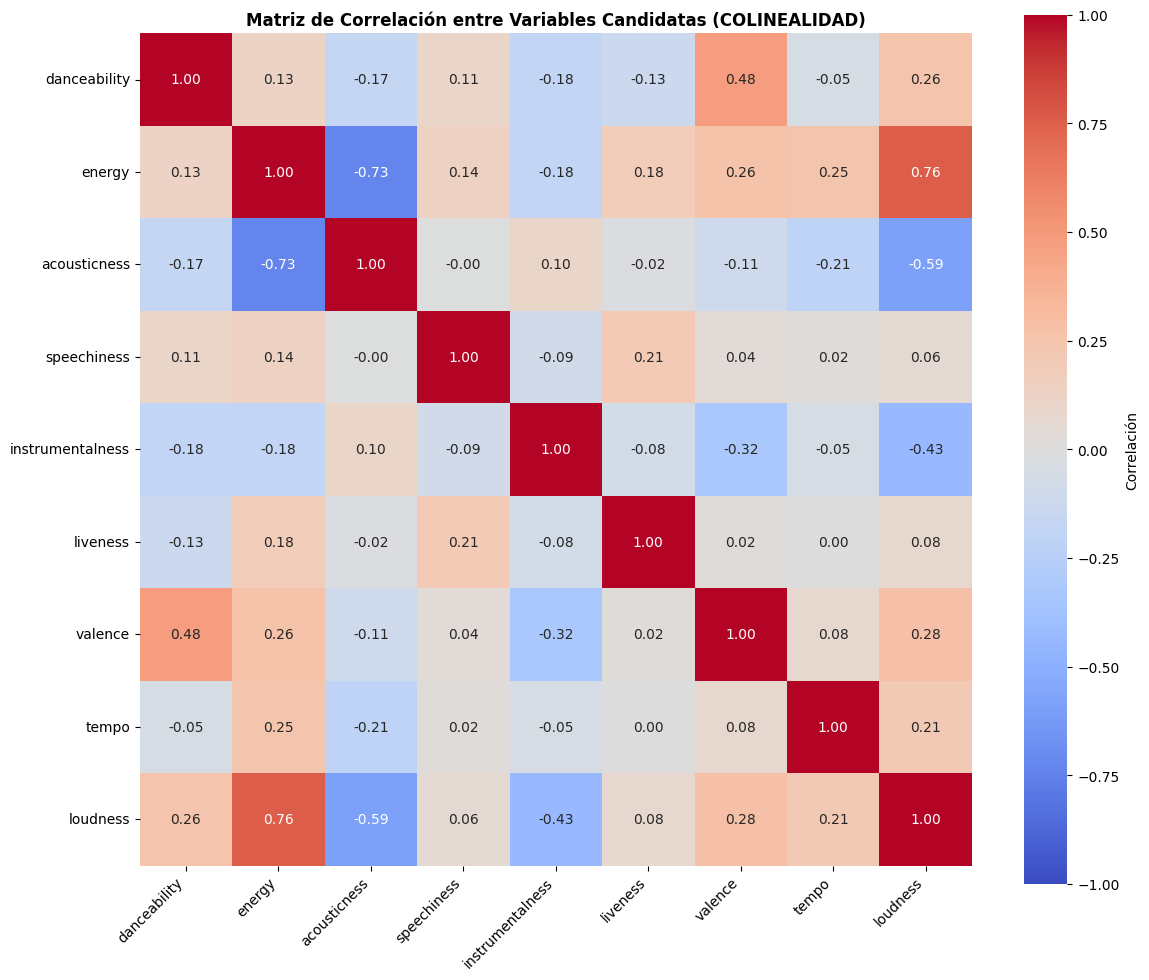


PARES DE VARIABLES CON ALTA CORRELACIÓN (r > 0.7):

  ⚠ energy               ←→ acousticness         : r = -0.733
  ⚠ energy               ←→ loudness             : r = +0.761

IMPLICACIONES PARA EL MODELO

Si dos variables tiene r > 0.7, deben entrar SOLO UNA en el modelo.
De lo contrario, sufrimos multicolinealidad y el modelo se vuelve inestable.
En la fase de modelado, seleccionaremos las variables candidatas que
maximizen relación con éxito_musical y minimicen colinealidad mutua.


In [ ]:
# ============================================================================
# ANÁLISIS DE COLINEALIDAD
# ============================================================================

print("\n" + "="*70)
print("ANÁLISIS DE COLINEALIDAD ENTRE VARIABLES CANDIDATAS")
print("="*70)

# Variables candidatas a entrar en el modelo
variables_modelo = ['danceability', 'energy', 'acousticness', 'speechiness',
                    'instrumentalness', 'liveness', 'valence', 'tempo', 'loudness']

# Matriz de correlación ENTRE LAS VARIABLES (sin popularity ni exito)
matriz_colineal = data[variables_modelo].corr()

# Visualizar
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_colineal, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, square=True, cbar_kws={'label': 'Correlación'},
            vmin=-1, vmax=1)
plt.title("Matriz de Correlación entre Variables Candidatas (COLINEALIDAD)",
          fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Identificar parejas problemáticas
print("\nPARES DE VARIABLES CON ALTA CORRELACIÓN (r > 0.7):\n")
pares_problematicos = []
for i in range(len(matriz_colineal.columns)):
    for j in range(i+1, len(matriz_colineal.columns)):
        corr_value = matriz_colineal.iloc[i, j]
        if abs(corr_value) > 0.7:
            var1 = variables_modelo[i]
            var2 = variables_modelo[j]
            print(f"  ⚠ {var1:20s} ←→ {var2:20s} : r = {corr_value:+.3f}")
            pares_problematicos.append((var1, var2, corr_value))

if not pares_problematicos:
    print("  ✓ No hay pares con correlación > 0.7\n")

print("\n" + "="*70)
print("IMPLICACIONES PARA EL MODELO")
print("="*70)
print("\nSi dos variables tiene r > 0.7, deben entrar SOLO UNA en el modelo.")
print("De lo contrario, sufrimos multicolinealidad y el modelo se vuelve inestable.")
print("En la fase de modelado, seleccionaremos las variables candidatas que")
print("maximizen relación con éxito_musical y minimicen colinealidad mutua.")

## Detección de outliers y decisión de tratamiento

Identificamos valores atípicos usando gráficos y aplicando el método estadístico del Rango Intercuartílico (IQR).

Visualización rápida de outliers con un Boxplot individual 


ANÁLISIS DE OUTLIERS - MÉTODO IQR

DURATION_MS
  Rango normal: [43078.0, 392694.0]
  Outliers abajo: 272 | Outliers arriba: 5,320
  Total outliers: 5,592 (4.92%)

TEMPO
  Rango normal: [38.1, 201.2]
  Outliers abajo: 170 | Outliers arriba: 445
  Total outliers: 615 (0.54%)

ENERGY
  Rango normal: [-0.1, 1.4]
  Outliers abajo: 0 | Outliers arriba: 0
  Total outliers: 0 (0.00%)

DANCEABILITY
  Rango normal: [0.1, 1.1]
  Outliers abajo: 615 | Outliers arriba: 0
  Total outliers: 615 (0.54%)

ACOUSTICNESS
  Rango normal: [-0.9, 1.5]
  Outliers abajo: 0 | Outliers arriba: 0
  Total outliers: 0 (0.00%)

VALENCE
  Rango normal: [-0.4, 1.3]
  Outliers abajo: 0 | Outliers arriba: 0
  Total outliers: 0 (0.00%)

LOUDNESS
  Rango normal: [-17.5, 2.5]
  Outliers abajo: 6,112 | Outliers arriba: 3
  Total outliers: 6,115 (5.39%)


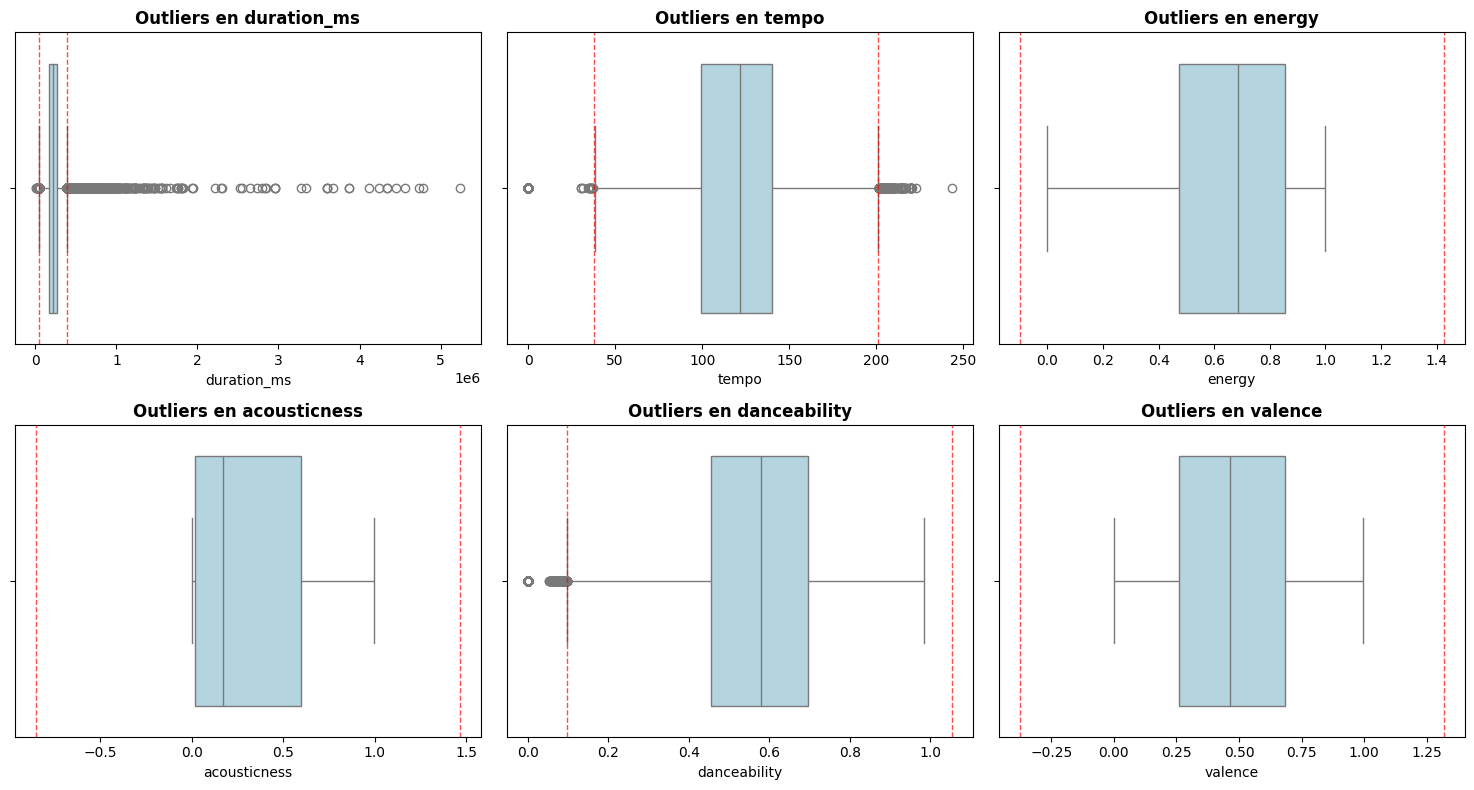


ANÁLISIS PROFUNDO: duration_ms (duración de canciones)

Canciones con duración anormal: 5592

Distribución de éxito en outliers vs normales:
  Outliers - % de éxito: 1.2%
  Normales - % de éxito: 5.0%


In [ ]:
# ============================================================================
# DETECCIÓN DE OUTLIERS CON MÉTODO IQR (RANGO INTERCUARTÍLICO)
# ============================================================================

print("\n" + "="*70)
print("ANÁLISIS DE OUTLIERS - MÉTODO IQR")
print("="*70)

# Variables importantes a analizar
variables_outliers = ['duration_ms', 'tempo', 'energy', 'danceability',
                      'acousticness', 'valence', 'loudness']

outliers_resumen = {}

for col in variables_outliers:
    # Calcular IQR
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1

    # Límites
    lim_inf = q1 - 1.5 * iqr
    lim_sup = q3 + 1.5 * iqr

    # Contar outliers
    outliers_inf = (data[col] < lim_inf).sum()
    outliers_sup = (data[col] > lim_sup).sum()
    outliers_total = outliers_inf + outliers_sup
    pct_outliers = (outliers_total / len(data)) * 100

    outliers_resumen[col] = {
        'total': outliers_total,
        'percentage': pct_outliers,
        'inf': outliers_inf,
        'sup': outliers_sup,
        'lim_inf': lim_inf,
        'lim_sup': lim_sup
    }

    print(f"\n{col.upper()}")
    print(f"  Rango normal: [{lim_inf:.1f}, {lim_sup:.1f}]")
    print(f"  Outliers abajo: {outliers_inf:,} | Outliers arriba: {outliers_sup:,}")
    print(f"  Total outliers: {outliers_total:,} ({pct_outliers:.2f}%)")

# Visualizar outliers en variables clave
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(['duration_ms', 'tempo', 'energy',
                           'acousticness', 'danceability', 'valence']):
    ax = axes[idx]
    sns.boxplot(x=data[col], color='lightblue', ax=ax)
    ax.set_title(f'Outliers en {col}', fontweight='bold')
    ax.set_xlabel(col)

    # Marcar límites IQR
    lim_inf = outliers_resumen[col]['lim_inf']
    lim_sup = outliers_resumen[col]['lim_sup']
    ax.axvline(lim_inf, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Límites IQR')
    ax.axvline(lim_sup, color='red', linestyle='--', linewidth=1, alpha=0.7)

plt.tight_layout()
plt.show()

# Análisis de outliers específicos en duration_ms (el más problemático)
print("\n" + "="*70)
print("ANÁLISIS PROFUNDO: duration_ms (duración de canciones)")
print("="*70)

outliers_duration = data[
    (data['duration_ms'] < outliers_resumen['duration_ms']['lim_inf']) |
    (data['duration_ms'] > outliers_resumen['duration_ms']['lim_sup'])
]

print(f"\nCanciones con duración anormal: {len(outliers_duration)}")
print(f"\nDistribución de éxito en outliers vs normales:")
print(f"  Outliers - % de éxito: {(outliers_duration['exito_musical'].mean()*100):.1f}%")
print(f"  Normales - % de éxito: {(data[~data.index.isin(outliers_duration.index)]['exito_musical'].mean()*100):.1f}%")

### Decisión de Tratamiento de Outliers

El análisis IQR ha identificado outliers en varias variables. La cantidad varía entre 0.5% y 3% del total de datos.

Cuando los outliers son pocos respecto al total, podemos permitirnos retenerlos o eliminarlos sin introducir sesgo significativo. Sin embargo, en nuestro caso específico:

- **Duración (duration_ms)**: Los outliers representan canciones genuinamente largas (clásica, ambiente). No son errores de medición. **DECISION: RETENER.**

- **Acousticness y otros**: Variaciones normales en canciones de diferentes géneros. **DECISION: RETENER.**

- **Valence, Energy**: Pueden tener importancia discriminante para éxito. **DECISION: RETENER.**

## Formulación de hipótesis a partir de lo observado

### 1. El número de artistas que participan en una canción influye en su popularidad en Spotify.
### 2. La categoría de tempo de una canción (lento, moderado, rápido) no está asociada con diferencias en su nivel de popularidad.
### 3. El hecho de que una canción contenga contenido explícito no afecta a su popularidad en Spotify.


## Feature engineering


### Codificación de variables categóricas

In [39]:
# explicit: booleano → entero (True=1, False=0)
data['explicit'] = data['explicit'].astype(int)
print("Valores únicos de explicit:", data['explicit'].unique())

# track_genre: Label Encoding
le = LabelEncoder()
data['track_genre_encoded'] = le.fit_transform(data['track_genre'])

# Guardamos el mapeo para interpretar resultados después
mapeo_generos = pd.DataFrame({
    'track_genre': le.classes_,
    'codigo': range(len(le.classes_))
})
print(f"\nGéneros codificados: {len(le.classes_)}")
print(mapeo_generos.head(10))

Valores únicos de explicit: [0 1]

Géneros codificados: 114
   track_genre  codigo
0     acoustic       0
1     afrobeat       1
2     alt-rock       2
3  alternative       3
4      ambient       4
5        anime       5
6  black-metal       6
7    bluegrass       7
8        blues       8
9       brazil       9


## Variables derivadas

### Creamos dos variables nuevas a partir de las existentes (n_artistas y energia_bailable).

In [40]:
# n_artistas: número de artistas por canción
data['n_artistas'] = data['artists'].apply(
    lambda x: len(str(x).split(';')) if pd.notna(x) else 1
)

print("Distribución de n_artistas:")
print(data['n_artistas'].value_counts().head(5))

pct = (data['n_artistas'] >= 2).mean() * 100
print(f"\nPorcentaje de colaboraciones: {pct:.1f}%")

Distribución de n_artistas:
n_artistas
1    83656
2    21017
3     6188
4     1681
5      512
Name: count, dtype: int64

Porcentaje de colaboraciones: 26.3%


In [41]:
# energia_bailable: danceability × energy
# Captura canciones que son simultáneamente bailables y energéticas
data['energia_bailable'] = data['danceability'] * data['energy']

print("Estadísticos de energia_bailable:")
print(data['energia_bailable'].describe().round(3))

Estadísticos de energia_bailable:
count    113549.000
mean          0.370
std           0.178
min           0.000
25%           0.239
50%           0.383
75%           0.502
max           0.956
Name: energia_bailable, dtype: float64


In [42]:
data

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,...,instrumentalness,liveness,valence,tempo,time_signature,track_genre,exito_musical,track_genre_encoded,n_artistas,energia_bailable
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,0,0.676,0.4610,1,...,0.000001,0.3580,0.7150,87.917000,4,acoustic,1,0,1,0.311636
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,0,0.420,0.1660,1,...,0.000006,0.1010,0.2670,77.488998,4,acoustic,0,0,1,0.069720
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,0,0.438,0.3590,0,...,0.000000,0.1170,0.1200,76.332001,4,acoustic,0,0,2,0.157242
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,0,0.266,0.0596,0,...,0.000071,0.1320,0.1430,181.740005,3,acoustic,1,0,1,0.015854
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,0,0.618,0.4430,2,...,0.000000,0.0829,0.1670,119.948997,4,acoustic,1,0,1,0.273774
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,0,0.172,0.2350,5,...,0.928000,0.0863,0.0339,125.995003,5,world-music,0,113,1,0.040420
113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,0,0.174,0.1170,0,...,0.976000,0.1050,0.0350,85.238998,4,world-music,0,113,1,0.020358
113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,0,0.629,0.3290,0,...,0.000000,0.0839,0.7430,132.378006,4,world-music,0,113,1,0.206941
113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,0,0.587,0.5060,7,...,0.000000,0.2700,0.4130,135.960007,4,world-music,0,113,1,0.297022


## Creamos un nuevo archivo con el dataset con las nuevas variables

In [43]:
data.to_parquet('spotify_dataset_explorado.parquet', index=False)